# AG-HYPOPT · Trial 12

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eleven trials are registered; cell 2 reports `phase = trials` (11/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_08 (0.1099, best, 0 div):** `lr_mu=0.1616`, `mu_anneal=0.3475`, `lr_gamma=0.4157`, `gamma_anneal=0.5318` (travel 0.134). mu 76.5%, gamma 23.1%.
- **trial_09 (0.1126, 0 div):** travel 0.123; mu 71.1%.
- **trial_01 (0.1127, 0 div):** travel 0.120; mu 77.1%, gamma 21.5%.
- **trial_05 (0.1135, 0 div):** travel 0.088; mu 56.6%.
- **trial_07 (0.1140, 0 div):** travel 0.097; mu 62.0%, gamma 21.6%.
- **trial_06 / trial_11 (0.1188, 0 div):** travels 0.082 / 0.159; trial_11 overshot the optimum.
- **trials 10 (0.1975, 1 div), 03 (0.1362), 04 (0.1418), 02 (0.1449):** the diverging runs (1nW T05 in 02/03/04, 3nW T60 in 10).

The defining result of the last rounds is that the mu-travel optimum is **bracketed near 0.134**: trial_09 (0.123) gave 0.1126, trial_08 (0.134) gave the best 0.1099, and trial_11 (0.159) fell back to 0.1188 with ballooning mid/low-T mu overshoots. So the objective minimum sits at travel ~0.134, and the best run pairs it with `lr_gamma~0.42`, `gamma_anneal~0.53`. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_12'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (11/5 trials)
ID |     ei | params
 1 | 2.8418 | {"gamma_anneal": 0.48241919351550183, "lr_gamma": 0.2203268398972022, "lr_mu": 0.08419508438746806, "mu_anneal": 0.33630302136597934}
 2 | 2.2161 | {"gamma_anneal": 0.5711088256341466, "lr_gamma": 0.5643928536328545, "lr_mu": 0.13268770458669019, "mu_anneal": 0.33928894989573216}
 3 | 3.9659 | {"gamma_anneal": 0.47969975028815254, "lr_gamma": 0.4774386713655748, "lr_mu": 0.15519021609909986, "mu_anneal": 0.3494467304397492}
 4 | 2.7162 | {"gamma_anneal": 0.8430265124362203, "lr_gamma": 0.39995064421172444, "lr_mu": 0.07725789234743274, "mu_anneal": 0.34510819937256726}
 5 | 0.5581 | {"gamma_anneal": 0.5017216698114564, "lr_gamma": 0.7754438351557879, "lr_mu": 0.47307233724280995, "mu_anneal": 0.600110285529601}
 6 | 2.5777 | {"gamma_anneal": 0.4369096219776836, "lr_gamma": 0.7913636612284496, "lr_mu": 0.1600744998010631, "mu_anneal": 0.331125496110027}
 7 | 3.9063 | {"gamma_anneal": 0.548096388532218, "lr_gamma": 0.490037

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (11 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 3: **ei 3.97** — `lr_mu=0.155`, `mu_anneal=0.349` (travel **0.128**), `lr_gamma=0.477`, `gamma_anneal=0.480`.
- candidate 7: ei 3.91 — `lr_mu=0.474`, `mu_anneal=0.364` (travel 0.387, the trial_02 direction), `lr_gamma=0.490`.
- candidate 8: ei 2.87 — `lr_mu=0.149`, `mu_anneal=0.318` (travel 0.125), `lr_gamma=0.529`, `gamma_anneal=0.576`.
- candidate 1: ei 2.84 — `lr_mu=0.084`, `mu_anneal=0.336` (travel 0.070), `lr_gamma=0.220`.
- candidate 4: ei 2.72 — `lr_mu=0.077`, `mu_anneal=0.345` (travel 0.064), `lr_gamma=0.400`, `gamma_anneal=0.843`.
- candidate 6: ei 2.58 — `lr_mu=0.160`, `mu_anneal=0.331` (travel 0.134), `lr_gamma=0.791`, `gamma_anneal=0.437`.

Candidate 3 has the highest ei **and** lands right at the bracket the last three trials established: travel 0.128 sits between trial_09's 0.123 and the best trial_08's 0.134. More striking, its mu knobs (`lr_mu=0.155`, `mu_anneal=0.349`) are almost exactly trial_08's (`0.162`/`0.348`), so this candidate is essentially trial_08 with slightly different gamma knobs (`lr_gamma=0.477`, `gamma_anneal=0.480` vs trial_08's `0.416`/`0.532`). That makes it a direct test of whether tuning the gamma schedule at the known mu optimum can push below 0.1099. The remaining candidates are weaker on the evidence: candidate 7 is far out at travel 0.387 (trial_02 territory, ei notwithstanding); candidates 1 and 4 sit at travels 0.064-0.070, below the band where divergences occurred; candidate 6 is at the same travel (0.134) but with a very different, high `lr_gamma=0.791` and low `gamma_anneal=0.437`, and lower ei. So candidate 3 is the highest-ei and the most on-target probe.

I choose candidate 3 (3 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.47969975028815254, 'lr_gamma': 0.4774386713655748, 'lr_mu': 0.15519021609909986, 'mu_anneal': 0.3494467304397492}
Running  1nW Trans05 ... 

μ 9.39 -> 10.30 | γ 8.5 -> 4.48 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 38.03 | γ 8.5 -> 6.13 | NLL 4.90


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 79.20 | γ 14.1 -> 14.46 | NLL 3.22


Running 3nW Trans100 ... 

μ 175.71 -> 111.34 | γ 14.1 -> 14.02 | NLL 3.44



Total: 7.8 min


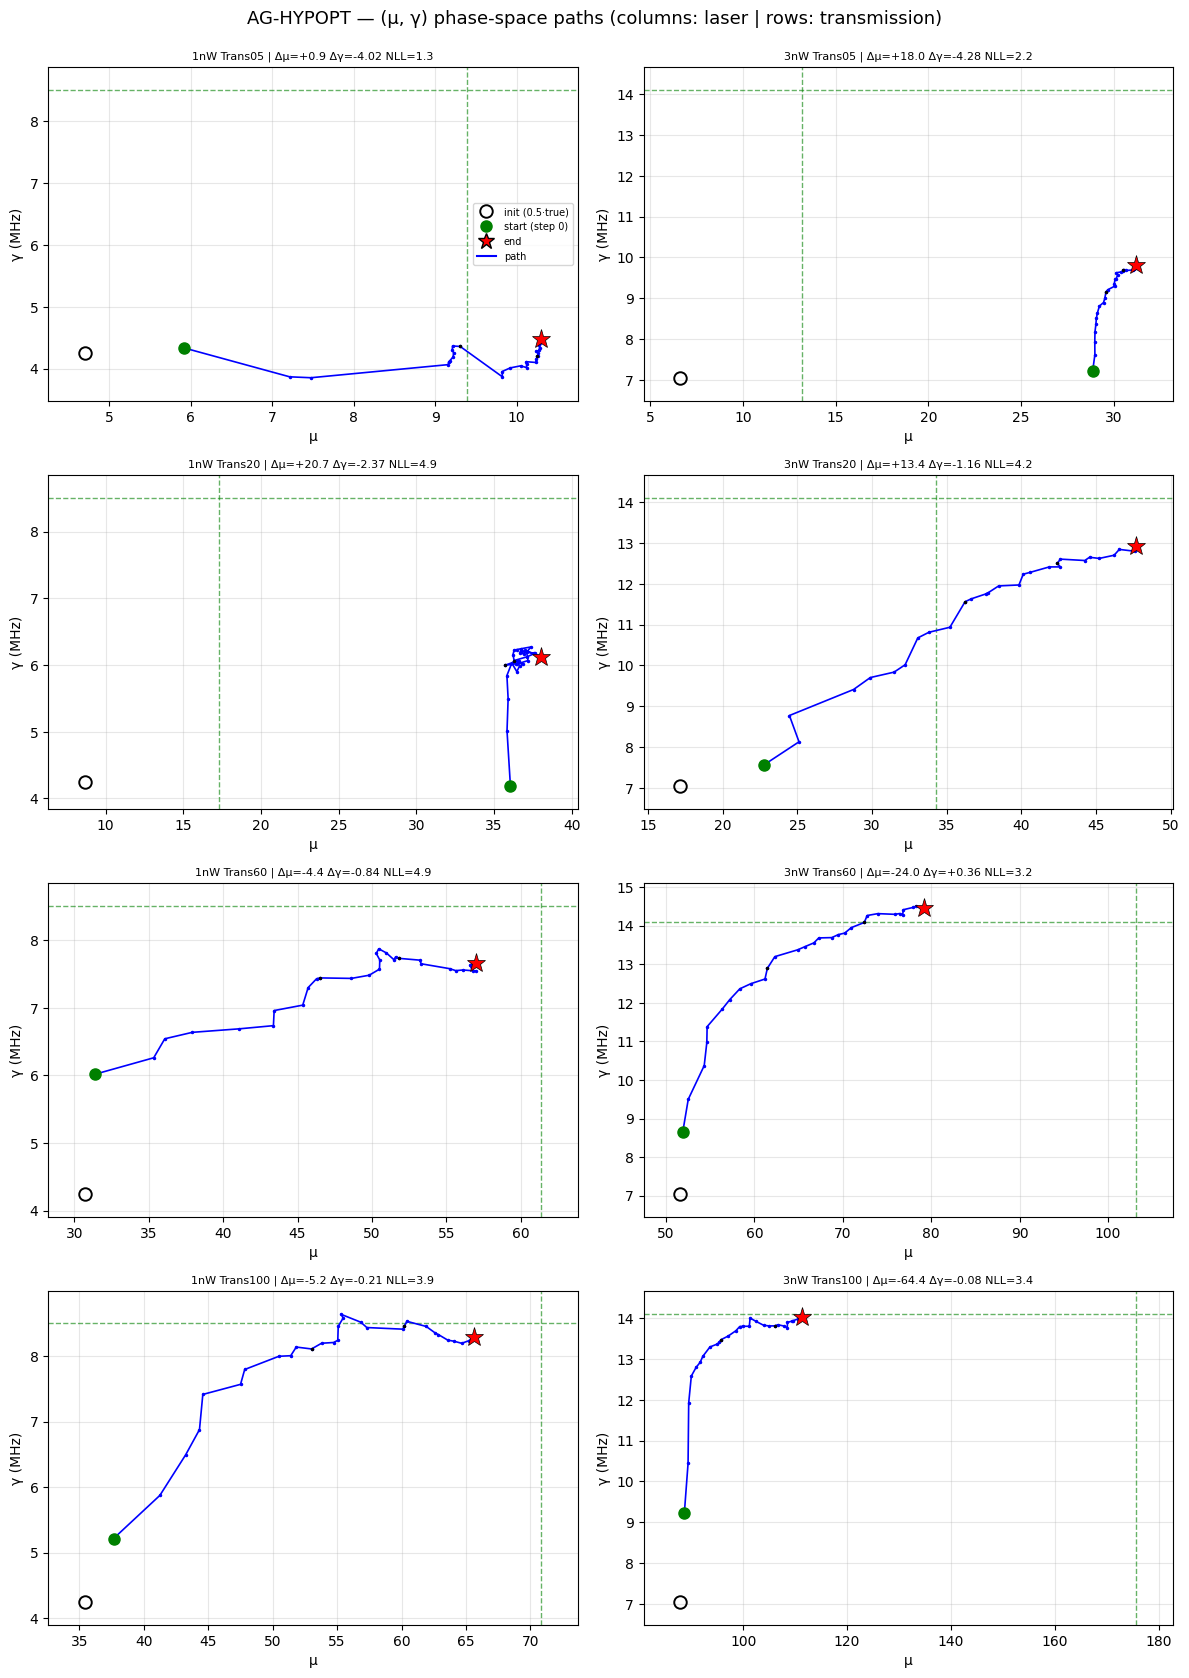

trial finished in 7.8 min
objective = 0.1115 ± 0.0824
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.30    +9.6 |     8.50    4.48   -47.3
1nW Trans20       17.32   38.03  +119.6 |     8.50    6.13   -27.9
1nW Trans60       61.37   57.00    -7.1 |     8.50    7.66    -9.8
1nW Trans100       70.82   65.61    -7.4 |     8.50    8.29    -2.4
3nW Trans05       13.20   31.22  +136.5 |    14.10    9.82   -30.3
3nW Trans20       34.28   47.69   +39.1 |    14.10   12.94    -8.2
3nW Trans60      103.20   79.20   -23.3 |    14.10   14.46    +2.6
3nW Trans100      175.71  111.34   -36.6 |    14.10   14.02    -0.5

weighted objective (T-graded, cap=1.0) = 0.1115 | diverged cells: 0
μ: RMSE 26.693 (rel 67.6%, bias -5.612) | γ: RMSE 2.300 (rel 22.7%, bias -1.573)


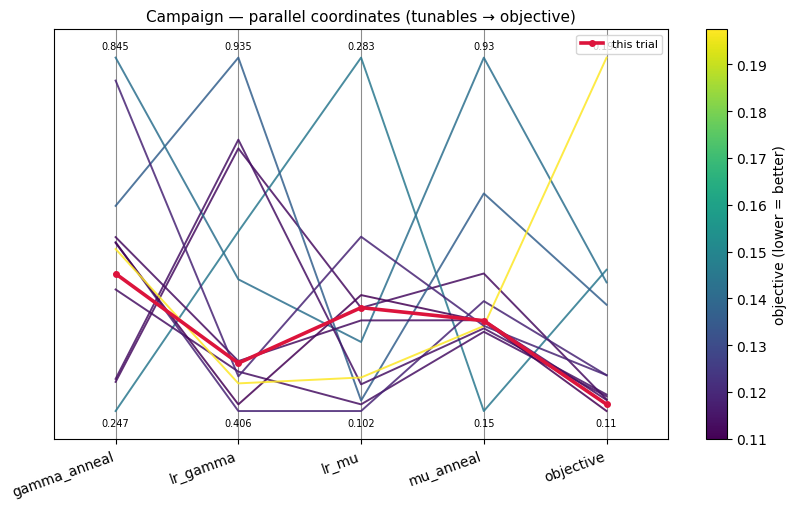

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 12 ran the highest-EI candidate (candidate 3, ei=3.97): `lr_mu=0.1552`, `mu_anneal=0.3494` (effective mu travel 0.128), `lr_gamma=0.4774`, `gamma_anneal=0.4797`. It completed in 7.8 min with objective **0.1115 +/- 0.0824** and **0 diverged cells** — second-best of the campaign, just above trial_08 (0.1099). Ranking: trial_08 0.1099 < **trial_12 0.1115** < trial_09 0.1126 < trial_01 0.1127 < trial_05 0.1135 < trial_07 0.1140 < trial_06 = trial_11 0.1188 < ...

Aggregate accuracy: **mu rel-RMSE 67.6%** (RMSE 26.69, bias -5.61); **gamma rel-RMSE 22.7%** (RMSE 2.30, bias -1.57).

Per-cell relative errors:
- **mu:** 1nW T05 +9.6%, T20 +119.6%, T60 -7.1%, T100 -7.4% | 3nW T05 +136.5%, T20 +39.1%, T60 -23.3%, T100 -36.6%.
- **gamma:** 1nW T05 -47.3%, T20 -27.9%, T60 -9.8%, T100 -2.4% | 3nW T05 -30.3%, T20 -8.2%, T60 +2.6%, T100 -0.5%.

This was deliberately the tightest possible test of the best region: its mu knobs (`lr_mu=0.155`, `mu_anneal=0.349`) are essentially trial_08's (`0.162`/`0.348`), with the gamma schedule changed (`lr_gamma` 0.477 vs 0.416; `gamma_anneal` 0.480 vs 0.532). It landed at 0.1115 — extremely close to trial_08 but not better. Notably the 1nW high-T mu results did **not** fully reproduce trial_08's (1nW T60 -7.1% / T100 -7.4% here vs -2.7% / -2.5% in trial_08), despite near-identical mu knobs, so even that favourable cell is sensitive to the gamma schedule. Net: changing the gamma knobs at the mu optimum shifts the objective by only ~0.002, confirming the optimum region is flat in both directions; trial_08's exact combination remains the best.

**Summary:** Trial 12 (lr_mu=0.1552, mu_anneal=0.3494, lr_gamma=0.4774, gamma_anneal=0.4797): objective 0.1115 +/- 0.0824 with 0 diverged cells; essentially trial_08's mu knobs with different gamma knobs, it landed second-best (just above trial_08's 0.1099), so gamma-schedule changes at the mu optimum do not beat trial_08.
**Key insight:** At the mu optimum (travel ~0.13), changing the gamma schedule (`lr_gamma` 0.416 -> 0.477, `gamma_anneal` 0.532 -> 0.480) leaves the objective essentially unchanged (0.1099 -> 0.1115), and even the 1nW high-T mu result no longer reproduces exactly - the objective is flat to ~0.002 here and trial_08 stays best.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Trials 08, 09 and 12 are nearly the same mu schedule with different gamma knobs and all land in 0.1099-0.1126; the differences in their per-cell errors are not attributable to any single knob, which suggests the residual spread at the optimum is a run-to-run/deterministic-chaotic sensitivity rather than a tunable. The dominant remaining errors (mid-T mu overshoot ~+120-137%, 3nW high-T mu undershoot ~-23% to -37%, low-T gamma under-recovery ~-30% to -47%) are unchanged across this whole neighbourhood — the standing structural argument; recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 12 (lr_mu=0.1552, mu_anneal=0.3494, lr_gamma=0.4774, gamma_anneal=0.4797): objective 0.1115 +/- 0.0824 with 0 diverged cells; essentially trial_08's mu knobs with different gamma knobs, it landed second-best (just above trial_08's 0.1099), so gamma-schedule changes at the mu optimum do not beat trial_08"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "At the mu optimum (travel ~0.13), changing the gamma schedule (lr_gamma 0.416 -> 0.477, gamma_anneal 0.532 -> 0.480) leaves the objective essentially unchanged (0.1099 -> 0.1115), and even the 1nW high-T mu result no longer reproduces exactly - the objective is flat to ~0.002 here and trial_08 stays best"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_12 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_13.ipynb. Open it and follow its cells from the top.
